# Semana 12 — Evaluación Monte Carlo y TD(0)

**Modelos de Decisión en el Tiempo — Módulo 3: Aprendizaje por Refuerzo Tabular**

En esta sesión construiremos entornos financieros sencillos y estudiaremos dos formas de evaluar una política a partir de simulaciones:

- **Monte Carlo (MC):** espera hasta completar una trayectoria y utiliza el retorno total observado.
- **TD(0):** actualiza el valor después de cada transición, sin esperar hasta el final.

La programación sigue la progresión de las semanas anteriores: variables, arreglos, ciclos, condicionales y funciones sencillas. No utilizaremos clases, `zip`, `enumerate`, comprensiones de listas o diccionarios, ni funciones anónimas.


### Convención para los problemas de horizonte finito

En un problema finito, el valor depende del tiempo restante. Para no añadir el tiempo al estado, estimaremos únicamente el valor **al comienzo del horizonte**:

$$
V_0^\pi(s)
=
\mathbb E_\pi\left[\sum_{t=0}^{T-1}\gamma^t R_{t+1}\mid S_0=s\right].
$$

Para estimar $V_0^\pi(s)$, iniciamos episodios separados directamente en cada estado $s$ y usamos el retorno completo desde $t=0$. Así no mezclamos visitas al mismo estado ocurridas en momentos con diferente cantidad de períodos restantes.


### Herramientas de la sesión

| Herramienta | Actualización |
|:---|:---|
| MC incremental | $\hat V(s) \leftarrow \hat V(s)+\frac{1}{N(s)}[G-\hat V(s)]$ |
| TD(0) | $\hat V(s) \leftarrow \hat V(s)+\alpha[r+\gamma\hat V(s')-\hat V(s)]$ |
| Evaluación exacta finita | Recursión hacia atrás para una política fija |

> En los ejercicios finitos de mercado y apuestas, MC estima $V_0(s)$ iniciando desde cada estado. En el market maker utilizaremos una tarea continua descontada, donde una sola función estacionaria $V(s)$ sí es apropiada.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


---

## Ejercicio 1 — Regímenes de mercado y evaluación Monte Carlo

**Valorem Capital S.A.S.** modela el mercado accionario colombiano con tres regímenes: Alcista, Lateral y Bajista. Se comparan tres políticas fijas: Largo, Mixto y Defensivo.

| Componente | Definición |
|:---|:---|
| Estado | Régimen del mercado: Alcista, Lateral o Bajista |
| Acción | Largo, Mixto o Defensivo |
| Recompensa | Retorno mensual aleatorio en porcentaje |
| Horizonte | $T=24$ meses |
| Descuento | $\gamma=0.95$ |

La evaluación exacta no es iteración de valor: no estamos buscando una acción óptima. Evaluaremos cada política fija mediante una recursión de programación dinámica.


In [2]:
P_mercado = np.array([
    [0.55, 0.30, 0.15],
    [0.25, 0.50, 0.25],
    [0.20, 0.35, 0.45]
])

mu_mercado = np.array([
    [ 3.2,  2.0, 0.5],
    [ 0.1,  0.3, 0.5],
    [-4.5, -1.8, 0.5]
])

sigma_mercado = np.array([
    [4.1, 2.5, 0.3],
    [1.8, 1.0, 0.3],
    [5.2, 3.0, 0.3]
])

nombres_estado_mercado = [
    'Alcista', 'Lateral', 'Bajista'
]

nombres_politica_mercado = [
    'Largo', 'Mixto', 'Defensivo'
]

numero_estados_mercado = 3
numero_politicas_mercado = 3
gamma_mercado = 0.95
horizonte_mercado = 24


### Un paso del entorno

Partimos del régimen Alcista y aplicamos la política Largo. El retorno depende del estado y de la política; la transición del régimen depende únicamente del estado actual.


In [3]:
np.random.seed(42)

estado_actual = 0
accion_actual = 0

retorno = np.random.normal(
    mu_mercado[estado_actual, accion_actual],
    sigma_mercado[estado_actual, accion_actual]
)

estado_siguiente = np.random.choice(
    numero_estados_mercado,
    p=P_mercado[estado_actual, :]
)

print('Estado actual:', nombres_estado_mercado[estado_actual])
print('Política:', nombres_politica_mercado[accion_actual])
print('Retorno mensual:', round(retorno, 2), '%')
print('Estado siguiente:', nombres_estado_mercado[estado_siguiente])


Estado actual: Alcista
Política: Largo
Retorno mensual: 5.24 %
Estado siguiente: Lateral


### Un episodio desde un estado inicial fijo

Para estimar $V_0(	ext{Alcista})$, el episodio comienza en Alcista y acumulamos el retorno completo de los 24 meses. No usamos visitas posteriores a Alcista para estimar el mismo valor, porque ocurren con menos meses restantes.


In [4]:
np.random.seed(123)

estado_actual = 0
accion_fija = 0

estados_episodio = np.zeros(
    horizonte_mercado,
    dtype=int
)

recompensas_episodio = np.zeros(
    horizonte_mercado
)

for periodo in range(horizonte_mercado):

    estados_episodio[periodo] = estado_actual

    recompensa = np.random.normal(
        mu_mercado[estado_actual, accion_fija],
        sigma_mercado[estado_actual, accion_fija]
    )

    recompensas_episodio[periodo] = recompensa

    estado_actual = np.random.choice(
        numero_estados_mercado,
        p=P_mercado[estado_actual, :]
    )

retorno_total = 0.0

for periodo in range(
    horizonte_mercado - 1,
    -1,
    -1
):
    retorno_total = (
        recompensas_episodio[periodo]
        + gamma_mercado * retorno_total
    )

print('Primeros cinco estados:')
for periodo in range(5):
    print(
        periodo,
        nombres_estado_mercado[
            estados_episodio[periodo]
        ],
        round(recompensas_episodio[periodo], 2)
    )

print('Retorno descontado del episodio:', round(retorno_total, 2), '%')


Primeros cinco estados:
0 Alcista -1.25
1 Alcista 7.29
2 Lateral -0.94
3 Bajista 4.09
4 Bajista -17.12
Retorno descontado del episodio: -5.82 %


### Funciones para repetir el experimento

La política se representa mediante un índice fijo: 0 para Largo, 1 para Mixto y 2 para Defensivo. No es necesario pasar funciones como argumentos.


In [5]:
def paso_mercado(estado_actual, accion_actual):

    recompensa = np.random.normal(
        mu_mercado[estado_actual, accion_actual],
        sigma_mercado[estado_actual, accion_actual]
    )

    estado_siguiente = np.random.choice(
        numero_estados_mercado,
        p=P_mercado[estado_actual, :]
    )

    return recompensa, estado_siguiente


def estimar_v0_mercado(
    accion_fija,
    numero_episodios,
    semilla
):

    np.random.seed(semilla)

    valores = np.zeros(numero_estados_mercado)
    historial_alcista = np.zeros(numero_episodios)

    for estado_inicial in range(
        numero_estados_mercado
    ):

        promedio = 0.0

        for episodio in range(numero_episodios):

            estado_actual = estado_inicial
            recompensas = np.zeros(
                horizonte_mercado
            )

            for periodo in range(
                horizonte_mercado
            ):

                recompensa, estado_siguiente = (
                    paso_mercado(
                        estado_actual,
                        accion_fija
                    )
                )

                recompensas[periodo] = recompensa
                estado_actual = estado_siguiente

            retorno_total = 0.0

            for periodo in range(
                horizonte_mercado - 1,
                -1,
                -1
            ):
                retorno_total = (
                    recompensas[periodo]
                    + gamma_mercado * retorno_total
                )

            promedio = promedio + (
                retorno_total - promedio
            ) / (episodio + 1)

            if estado_inicial == 0:
                historial_alcista[episodio] = promedio

        valores[estado_inicial] = promedio

    return valores, historial_alcista


In [6]:
numero_episodios_mercado = 800

valores_mc_mercado = np.zeros(
    (numero_politicas_mercado,
     numero_estados_mercado)
)

historiales_mercado = np.zeros(
    (numero_politicas_mercado,
     numero_episodios_mercado)
)

for politica in range(
    numero_politicas_mercado
):

    valores, historial = estimar_v0_mercado(
        accion_fija=politica,
        numero_episodios=numero_episodios_mercado,
        semilla=42
    )

    valores_mc_mercado[politica, :] = valores
    historiales_mercado[politica, :] = historial

    print()
    print('Política:', nombres_politica_mercado[politica])

    for estado in range(numero_estados_mercado):
        print(
            nombres_estado_mercado[estado],
            round(valores[estado], 2),
            '%'
        )



Política: Largo
Alcista 4.63 %
Lateral -1.42 %
Bajista -7.12 %

Política: Mixto
Alcista 7.44 %
Lateral 4.2 %
Bajista 1.61 %

Política: Defensivo
Alcista 7.12 %
Lateral 7.1 %
Bajista 7.09 %


### Evaluación exacta de una política fija

Para una política constante, calculamos hacia atrás:

$$
V_t(s)=\mu(s,a)+\gamma\sum_{s'}P(s'\mid s)V_{t+1}(s'),
\qquad V_T(s)=0.
$$


In [7]:
def evaluar_politica_mercado_exacta(
    accion_fija
):

    valor_siguiente = np.zeros(
        numero_estados_mercado
    )

    for periodo in range(
        horizonte_mercado - 1,
        -1,
        -1
    ):

        valor_actual = np.zeros(
            numero_estados_mercado
        )

        for estado_actual in range(
            numero_estados_mercado
        ):

            continuacion = 0.0

            for estado_siguiente in range(
                numero_estados_mercado
            ):

                continuacion = (
                    continuacion
                    + P_mercado[
                        estado_actual,
                        estado_siguiente
                    ]
                    * valor_siguiente[
                        estado_siguiente
                    ]
                )

            valor_actual[estado_actual] = (
                mu_mercado[
                    estado_actual,
                    accion_fija
                ]
                + gamma_mercado * continuacion
            )

        valor_siguiente = valor_actual.copy()

    return valor_siguiente


valores_exactos_mercado = np.zeros(
    (numero_politicas_mercado,
     numero_estados_mercado)
)

for politica in range(
    numero_politicas_mercado
):

    valores_exactos_mercado[politica, :] = (
        evaluar_politica_mercado_exacta(
            politica
        )
    )

print('Comparación MC y evaluación exacta:')

for politica in range(
    numero_politicas_mercado
):

    print()
    print('Política:', nombres_politica_mercado[politica])

    for estado in range(numero_estados_mercado):

        error = abs(
            valores_mc_mercado[politica, estado]
            - valores_exactos_mercado[
                politica, estado
            ]
        )

        print(
            nombres_estado_mercado[estado],
            'MC =',
            round(
                valores_mc_mercado[
                    politica, estado
                ],
                2
            ),
            'Exacto =',
            round(
                valores_exactos_mercado[
                    politica, estado
                ],
                2
            ),
            'Error absoluto =',
            round(error, 2)
        )


Comparación MC y evaluación exacta:

Política: Largo
Alcista MC = 4.63 Exacto = 3.65 Error absoluto = 0.97
Lateral MC = -1.42 Exacto = -1.48 Error absoluto = 0.06
Bajista MC = -7.12 Exacto = -7.46 Error absoluto = 0.34

Política: Mixto
Alcista MC = 7.44 Exacto = 6.9 Error absoluto = 0.54
Lateral MC = 4.2 Exacto = 4.16 Error absoluto = 0.04
Bajista MC = 1.61 Exacto = 1.41 Error absoluto = 0.2

Política: Defensivo
Alcista MC = 7.12 Exacto = 7.08 Error absoluto = 0.04
Lateral MC = 7.1 Exacto = 7.08 Error absoluto = 0.02
Bajista MC = 7.09 Exacto = 7.08 Error absoluto = 0.01


### 🎨 Visualización proporcionada

La siguiente celda se entrega completa. No se evalúa la sintaxis de Matplotlib. El objetivo es interpretar cómo se estabiliza la estimación de $V_0(	ext{Alcista})$.


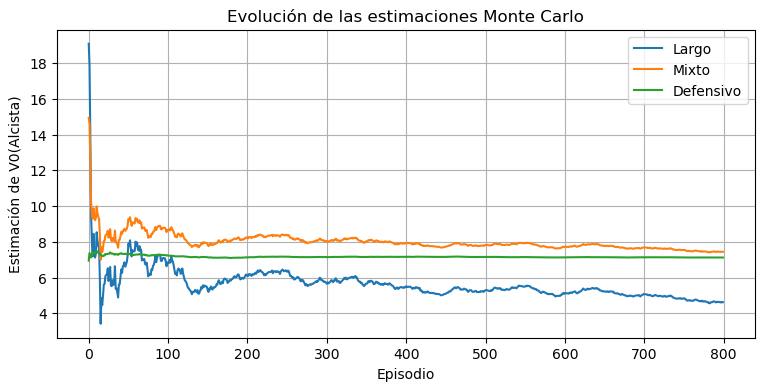

In [8]:
plt.figure(figsize=(9, 4))

for politica in range(
    numero_politicas_mercado
):

    plt.plot(
        historiales_mercado[politica, :],
        label=nombres_politica_mercado[
            politica
        ]
    )

plt.xlabel('Episodio')
plt.ylabel('Estimación de V0(Alcista)')
plt.title('Evolución de las estimaciones Monte Carlo')
plt.legend()
plt.grid()
plt.show()


---

## Ejercicio 2 — Criterio de Kelly con odds de Liga BetPlay

**QuiniElite S.A.S.** estima una probabilidad de acierto de 58% y una cuota promedio de 2.10.

$$
f^*=\frac{pb-q}{b}
=\frac{0.58(1.10)-0.42}{1.10}
\approx 0.1982.
$$

Por tanto, Kelly completo apuesta aproximadamente **19.8%** del capital y Medio Kelly aproximadamente **9.9%**.

En este ejercicio el capital evoluciona de forma continua. Para reportar $V_0(s)$ utilizaremos como capitales iniciales los valores enteros entre 0 y 20 millones de COP. Se considera ruina cuando el capital cae por debajo de 1 millón de COP. Esto evita los estados artificialmente inmóviles creados por redondear el capital después de cada apuesta.

> Kelly maximiza el crecimiento logarítmico esperado en su modelo clásico. Aquí también reportaremos capital esperado y probabilidad de ruina; esas métricas no son idénticas al criterio que origina la regla de Kelly. Además, el techo de 20 millones modifica el problema clásico, por lo que Kelly se interpreta aquí como una política heurística.


In [9]:
probabilidad_ganar = 0.58
cuota = 2.10
ganancia_neta = cuota - 1.0

fraccion_kelly = (
    probabilidad_ganar * ganancia_neta
    - (1.0 - probabilidad_ganar)
) / ganancia_neta

fraccion_medio_kelly = fraccion_kelly / 2.0
fraccion_fija = 0.05

fracciones = np.array([
    fraccion_kelly,
    fraccion_medio_kelly,
    fraccion_fija
])

nombres_estrategia = [
    'Kelly completo',
    'Medio Kelly',
    'Fija 5%'
]

capital_maximo = 20.0
umbral_ruina = 1.0
horizonte_kelly = 38
numero_estrategias = 3

print('Kelly completo:', round(fraccion_kelly * 100, 2), '%')
print('Medio Kelly:', round(fraccion_medio_kelly * 100, 2), '%')
print('Apuesta fija:', round(fraccion_fija * 100, 2), '%')


Kelly completo: 19.82 %
Medio Kelly: 9.91 %
Apuesta fija: 5.0 %


### Un paso de la estrategia Kelly

In [10]:
np.random.seed(42)

capital_actual = 10.0
fraccion = fraccion_kelly
apuesta = capital_actual * fraccion

if np.random.random() < probabilidad_ganar:
    capital_nuevo = capital_actual + (
        apuesta * ganancia_neta
    )
    resultado = 'Gana'
else:
    capital_nuevo = capital_actual - apuesta
    resultado = 'Pierde'

if capital_nuevo > capital_maximo:
    capital_nuevo = capital_maximo

if capital_nuevo < umbral_ruina:
    capital_nuevo = 0.0

recompensa = capital_nuevo - capital_actual

print('Capital inicial:', capital_actual, 'M COP')
print('Fracción apostada:', round(fraccion, 4))
print('Apuesta:', round(apuesta, 2), 'M COP')
print('Resultado:', resultado)
print('Capital nuevo:', round(capital_nuevo, 2), 'M COP')
print('Recompensa:', round(recompensa, 2), 'M COP')


Capital inicial: 10.0 M COP
Fracción apostada: 0.1982
Apuesta: 1.98 M COP
Resultado: Gana
Capital nuevo: 12.18 M COP
Recompensa: 2.18 M COP


In [11]:
def paso_apuesta(capital_actual, fraccion):

    if capital_actual == 0.0:
        return 0.0, 0.0, True

    apuesta = capital_actual * fraccion

    if np.random.random() < probabilidad_ganar:
        capital_nuevo = capital_actual + (
            apuesta * ganancia_neta
        )
    else:
        capital_nuevo = capital_actual - apuesta

    if capital_nuevo > capital_maximo:
        capital_nuevo = capital_maximo

    if capital_nuevo < umbral_ruina:
        capital_nuevo = 0.0

    recompensa = capital_nuevo - capital_actual
    termino = capital_nuevo == 0.0

    return capital_nuevo, recompensa, termino


### Trayectorias ilustrativas

Estas gráficas son proporcionadas. Se evalúa la interpretación de la variabilidad y del riesgo, no la sintaxis de Matplotlib.


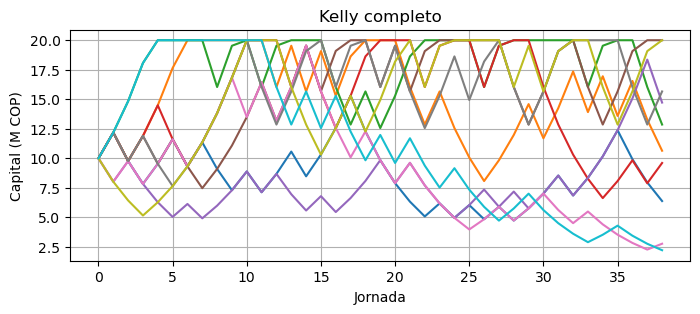

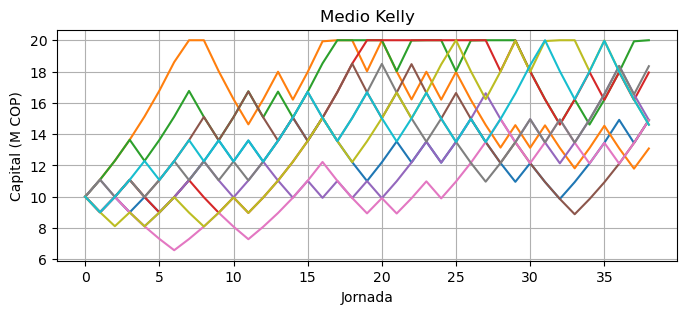

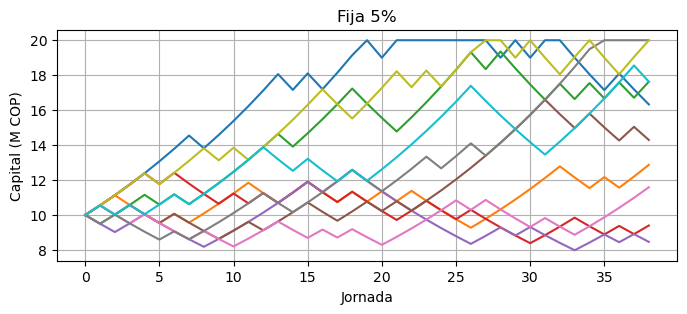

In [12]:
for estrategia in range(numero_estrategias):

    plt.figure(figsize=(8, 3))

    for trayectoria in range(10):

        np.random.seed(
            1000 * estrategia + trayectoria
        )

        capital_actual = 10.0
        capitales = np.zeros(
            horizonte_kelly + 1
        )
        capitales[0] = capital_actual

        for jornada in range(horizonte_kelly):

            capital_actual, recompensa, termino = (
                paso_apuesta(
                    capital_actual,
                    fracciones[estrategia]
                )
            )

            capitales[jornada + 1] = (
                capital_actual
            )

            if termino:
                for jornada_restante in range(
                    jornada + 1,
                    horizonte_kelly
                ):
                    capitales[
                        jornada_restante + 1
                    ] = 0.0
                break

        plt.plot(capitales)

    plt.xlabel('Jornada')
    plt.ylabel('Capital (M COP)')
    plt.title(nombres_estrategia[estrategia])
    plt.grid()
    plt.show()


### Evaluación de $V_0(s)$

Cada estimación comienza directamente en el capital inicial $s$. El retorno acumulado es simplemente el cambio total del capital, porque $\gamma=1$:

$$
G_0=W_T-W_0.
$$


In [13]:
def evaluar_kelly_desde_capital(
    fraccion,
    capital_inicial,
    numero_episodios,
    semilla
):

    np.random.seed(semilla)

    retornos = np.zeros(numero_episodios)
    capitales_finales = np.zeros(
        numero_episodios
    )

    for episodio in range(numero_episodios):

        capital_actual = float(capital_inicial)

        for jornada in range(horizonte_kelly):

            capital_actual, recompensa, termino = (
                paso_apuesta(
                    capital_actual,
                    fraccion
                )
            )

            if termino:
                break

        retornos[episodio] = (
            capital_actual - capital_inicial
        )

        capitales_finales[episodio] = (
            capital_actual
        )

    return retornos, capitales_finales


In [14]:
numero_episodios_kelly = 500
capitales_iniciales = np.zeros(21)

for capital in range(21):
    capitales_iniciales[capital] = capital

valores_kelly = np.zeros(
    (numero_estrategias, 21)
)

for capital_inicial in range(21):

    for estrategia in range(
        numero_estrategias
    ):

        retornos, capitales_finales = (
            evaluar_kelly_desde_capital(
                fracciones[estrategia],
                capital_inicial,
                numero_episodios_kelly,
                semilla=5000 + capital_inicial
            )
        )

        valores_kelly[
            estrategia,
            capital_inicial
        ] = np.mean(retornos)

print('Valor estimado desde 10 M COP:')

for estrategia in range(numero_estrategias):
    print(
        nombres_estrategia[estrategia],
        round(valores_kelly[estrategia, 10], 3),
        'M COP'
    )


Valor estimado desde 10 M COP:
Kelly completo 1.668 M COP
Medio Kelly 4.651 M COP
Fija 5% 4.267 M COP


### Intervalos y probabilidad de ruina desde 10 millones

Usaremos una semilla común para que los experimentos sean reproducibles. Los intervalos que siguen describen cada estrategia por separado; no son intervalos emparejados.


In [15]:
numero_episodios_comparacion = 2000

medias_kelly = np.zeros(numero_estrategias)
errores_95_kelly = np.zeros(
    numero_estrategias
)
probabilidades_ruina = np.zeros(
    numero_estrategias
)

for estrategia in range(numero_estrategias):

    retornos, capitales_finales = (
        evaluar_kelly_desde_capital(
            fracciones[estrategia],
            capital_inicial=10.0,
            numero_episodios=(
                numero_episodios_comparacion
            ),
            semilla=777
        )
    )

    medias_kelly[estrategia] = (
        np.mean(retornos)
    )

    desviacion = np.std(
        retornos,
        ddof=1
    )

    errores_95_kelly[estrategia] = (
        1.96
        * desviacion
        / np.sqrt(
            numero_episodios_comparacion
        )
    )

    ruinas = 0

    for episodio in range(
        numero_episodios_comparacion
    ):

        if capitales_finales[episodio] == 0.0:
            ruinas = ruinas + 1

    probabilidades_ruina[estrategia] = (
        ruinas
        / numero_episodios_comparacion
    )

    print()
    print(nombres_estrategia[estrategia])
    print('Cambio medio:', round(medias_kelly[estrategia], 3))
    print('Margen IC 95%:', round(errores_95_kelly[estrategia], 3))
    print('Probabilidad de ruina:', round(100 * probabilidades_ruina[estrategia], 2), '%')



Kelly completo
Cambio medio: 2.142
Margen IC 95%: 0.257
Probabilidad de ruina: 1.7 %

Medio Kelly
Cambio medio: 4.832
Margen IC 95%: 0.193
Probabilidad de ruina: 0.0 %

Fija 5%
Cambio medio: 4.471
Margen IC 95%: 0.159
Probabilidad de ruina: 0.0 %


### 🎨 Visualización proporcionada

La siguiente gráfica muestra $V_0(s)$ para diferentes capitales iniciales. No se evalúa la sintaxis gráfica.


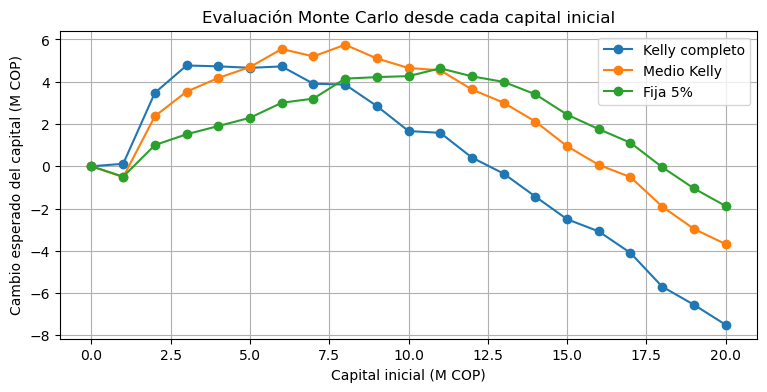

In [16]:
plt.figure(figsize=(9, 4))

for estrategia in range(numero_estrategias):
    plt.plot(
        capitales_iniciales,
        valores_kelly[estrategia, :],
        marker='o',
        label=nombres_estrategia[estrategia]
    )

plt.xlabel('Capital inicial (M COP)')
plt.ylabel('Cambio esperado del capital (M COP)')
plt.title('Evaluación Monte Carlo desde cada capital inicial')
plt.legend()
plt.grid()
plt.show()


---

## Ejercicio 3 — Market making simplificado en Ecopetrol

El market maker coloca órdenes bid y ask. Modelaremos una **tarea continua descontada**: la dinámica no termina después de un número fijo de pasos. Para estimar valores mediante MC usaremos retornos truncados a 300 pasos; para TD(0) entrenaremos sobre una trayectoria continua.

| Componente | Definición |
|:---|:---|
| Estado | Inventario $s\in\{-5,\ldots,5\}$ |
| Política | Spread fijo 1, 3 o 5 ticks |
| Fills | Probabilidad $0.6/	ext{spread}$ por lado |
| Precio | Cambio -1, 0 o +1 |
| Descuento | $\gamma=0.99$ |

Correcciones del entorno:

1. En inventario $+5$ no se permite una compra adicional; en $-5$ no se permite una venta adicional.
2. El PnL por movimiento de precio y la penalización utilizan el inventario **después** de los fills.


In [17]:
inventario_maximo = 5
gamma_market_maker = 0.99
horizonte_mc_market_maker = 300


def indice_inventario(inventario):
    indice = inventario + inventario_maximo
    return indice


### Un paso corregido del entorno

In [18]:
np.random.seed(2)

inventario_actual = 0
spread = 3
probabilidad_fill = 0.6 / spread

ganancia_spread = 0.0
inventario_nuevo = inventario_actual

# Fill ask: vender una unidad reduce el inventario.
if inventario_nuevo > -inventario_maximo:
    if np.random.random() < probabilidad_fill:
        inventario_nuevo = inventario_nuevo - 1
        ganancia_spread = ganancia_spread + spread * 0.5

# Fill bid: comprar una unidad aumenta el inventario.
if inventario_nuevo < inventario_maximo:
    if np.random.random() < probabilidad_fill:
        inventario_nuevo = inventario_nuevo + 1
        ganancia_spread = ganancia_spread + spread * 0.5

cambio_precio = np.random.choice(
    [-1, 0, 1],
    p=[0.3, 0.4, 0.3]
)

pnl_inventario = (
    cambio_precio * inventario_nuevo
)

penalizacion = (
    0.5 * inventario_nuevo**2 / 25.0
)

recompensa = (
    ganancia_spread
    + pnl_inventario
    - penalizacion
)

print('Inventario anterior:', inventario_actual)
print('Inventario posterior:', inventario_nuevo)
print('Ganancia por spread:', round(ganancia_spread, 3))
print('Cambio de precio:', cambio_precio)
print('PnL de inventario:', round(pnl_inventario, 3))
print('Penalización:', round(penalizacion, 3))
print('Recompensa:', round(recompensa, 3))

inventario_manual = inventario_nuevo
recompensa_manual = recompensa


Inventario anterior: 0
Inventario posterior: 1
Ganancia por spread: 1.5
Cambio de precio: 0
PnL de inventario: 0
Penalización: 0.02
Recompensa: 1.48


In [19]:
def paso_market_maker(
    inventario_actual,
    spread
):

    probabilidad_fill = 0.6 / spread
    inventario_nuevo = inventario_actual
    ganancia_spread = 0.0

    if inventario_nuevo > -inventario_maximo:
        if np.random.random() < probabilidad_fill:
            inventario_nuevo = inventario_nuevo - 1
            ganancia_spread = (
                ganancia_spread + spread * 0.5
            )

    if inventario_nuevo < inventario_maximo:
        if np.random.random() < probabilidad_fill:
            inventario_nuevo = inventario_nuevo + 1
            ganancia_spread = (
                ganancia_spread + spread * 0.5
            )

    cambio_precio = np.random.choice(
        [-1, 0, 1],
        p=[0.3, 0.4, 0.3]
    )

    pnl_inventario = (
        cambio_precio * inventario_nuevo
    )

    penalizacion = (
        0.5 * inventario_nuevo**2 / 25.0
    )

    recompensa = (
        ganancia_spread
        + pnl_inventario
        - penalizacion
    )

    return inventario_nuevo, recompensa


np.random.seed(2)
inventario_prueba, recompensa_prueba = (
    paso_market_maker(0, 3)
)

print('Coincide inventario:', inventario_prueba == inventario_manual)
print('Coincide recompensa:', abs(recompensa_prueba - recompensa_manual) < 1e-10)


Coincide inventario: True
Coincide recompensa: True


### Evaluación MC desde cada inventario inicial

Para no añadir el tiempo al estado, cada estimación de $V(s)$ comienza directamente en el inventario $s$ y utiliza un retorno descontado de 300 pasos. Este retorno truncado aproxima el valor de la tarea continua.


In [20]:
def estimar_v_market_maker_mc(
    spread,
    numero_episodios,
    semilla
):

    np.random.seed(semilla)

    numero_estados = (
        2 * inventario_maximo + 1
    )

    valores = np.zeros(numero_estados)
    historial_cero = np.zeros(
        numero_episodios
    )

    for inventario_inicial in range(
        -inventario_maximo,
        inventario_maximo + 1
    ):

        promedio = 0.0

        for episodio in range(numero_episodios):

            inventario_actual = inventario_inicial
            recompensas = np.zeros(
                horizonte_mc_market_maker
            )

            for paso in range(
                horizonte_mc_market_maker
            ):

                inventario_actual, recompensa = (
                    paso_market_maker(
                        inventario_actual,
                        spread
                    )
                )

                recompensas[paso] = recompensa

            retorno_total = 0.0

            for paso in range(
                horizonte_mc_market_maker - 1,
                -1,
                -1
            ):
                retorno_total = (
                    recompensas[paso]
                    + gamma_market_maker
                    * retorno_total
                )

            promedio = promedio + (
                retorno_total - promedio
            ) / (episodio + 1)

            if inventario_inicial == 0:
                historial_cero[episodio] = promedio

        indice = indice_inventario(
            inventario_inicial
        )
        valores[indice] = promedio

    return valores, historial_cero


In [21]:
spreads = np.array([1, 3, 5])
numero_spreads = len(spreads)
numero_episodios_mm = 150
numero_estados_mm = 11

valores_mc_mm = np.zeros(
    (numero_spreads, numero_estados_mm)
)

historiales_mc_mm = np.zeros(
    (numero_spreads, numero_episodios_mm)
)

for indice_spread in range(numero_spreads):

    valores, historial = (
        estimar_v_market_maker_mc(
            spreads[indice_spread],
            numero_episodios_mm,
            semilla=42
        )
    )

    valores_mc_mm[indice_spread, :] = valores
    historiales_mc_mm[
        indice_spread, :
    ] = historial

    print(
        'Spread',
        spreads[indice_spread],
        'V(0) =',
        round(
            valores[indice_inventario(0)],
            3
        )
    )


Spread 1 V(0) = 39.235
Spread 3 V(0) = 40.496
Spread 5 V(0) = 42.719


### Dos actualizaciones TD(0)

TD(0) actualiza después de cada transición. Como modelamos una tarea continua, siempre utilizamos el término de continuación $\gamma V(s')$.


In [22]:
alpha_td = 0.01
valor_td_demo = np.zeros(numero_estados_mm)

np.random.seed(2)
inventario_actual = 0

for paso in range(2):

    inventario_siguiente, recompensa = (
        paso_market_maker(
            inventario_actual,
            spread=3
        )
    )

    indice_actual = indice_inventario(
        inventario_actual
    )

    indice_siguiente = indice_inventario(
        inventario_siguiente
    )

    objetivo = (
        recompensa
        + gamma_market_maker
        * valor_td_demo[indice_siguiente]
    )

    error_td = (
        objetivo
        - valor_td_demo[indice_actual]
    )

    valor_td_demo[indice_actual] = (
        valor_td_demo[indice_actual]
        + alpha_td * error_td
    )

    print('Paso:', paso)
    print('Inventario:', inventario_actual)
    print('Inventario siguiente:', inventario_siguiente)
    print('Recompensa:', round(recompensa, 3))
    print('Objetivo TD:', round(objetivo, 3))
    print('Valor actualizado:', round(valor_td_demo[indice_actual], 4))
    print()

    inventario_actual = inventario_siguiente


Paso: 0
Inventario: 0
Inventario siguiente: 1
Recompensa: 1.48
Objetivo TD: 1.48
Valor actualizado: 0.0148

Paso: 1
Inventario: 1
Inventario siguiente: 1
Recompensa: -0.02
Objetivo TD: -0.02
Valor actualizado: -0.0002



In [23]:
def entrenar_td0_market_maker(
    spread,
    numero_pasos,
    alpha,
    semilla,
    frecuencia_registro
):

    np.random.seed(semilla)

    valores = np.zeros(numero_estados_mm)
    numero_registros = (
        numero_pasos // frecuencia_registro
    )
    historial = np.zeros(numero_registros)

    inventario_actual = 0
    indice_registro = 0

    for paso in range(numero_pasos):

        inventario_siguiente, recompensa = (
            paso_market_maker(
                inventario_actual,
                spread
            )
        )

        indice_actual = indice_inventario(
            inventario_actual
        )

        indice_siguiente = indice_inventario(
            inventario_siguiente
        )

        objetivo = (
            recompensa
            + gamma_market_maker
            * valores[indice_siguiente]
        )

        valores[indice_actual] = (
            valores[indice_actual]
            + alpha
            * (
                objetivo
                - valores[indice_actual]
            )
        )

        inventario_actual = inventario_siguiente

        if (
            (paso + 1) % frecuencia_registro
            == 0
        ):
            historial[indice_registro] = (
                valores[indice_inventario(0)]
            )
            indice_registro = (
                indice_registro + 1
            )

    return valores, historial


valores_td_mm, historial_td_mm = (
    entrenar_td0_market_maker(
        spread=3,
        numero_pasos=1000000,
        alpha=0.01,
        semilla=42,
        frecuencia_registro=1000
    )
)

print('MC aproximado V(0):', round(valores_mc_mm[1, indice_inventario(0)], 3))
print('TD(0) V(0):', round(valores_td_mm[indice_inventario(0)], 3))


MC aproximado V(0): 40.496
TD(0) V(0): 40.621


### Riesgo de inventario final

Simularemos una sola vez los inventarios finales y reutilizaremos el mismo arreglo para las métricas y la gráfica.


In [24]:
def simular_inventarios_finales(
    spread,
    numero_simulaciones,
    numero_pasos,
    semilla
):

    np.random.seed(semilla)

    inventarios_finales = np.zeros(
        numero_simulaciones,
        dtype=int
    )

    for simulacion in range(
        numero_simulaciones
    ):

        inventario_actual = 0

        for paso in range(numero_pasos):
            inventario_actual, recompensa = (
                paso_market_maker(
                    inventario_actual,
                    spread
                )
            )

        inventarios_finales[simulacion] = (
            inventario_actual
        )

    return inventarios_finales


numero_simulaciones_riesgo = 1000
inventarios_finales_mm = np.zeros(
    (numero_spreads,
     numero_simulaciones_riesgo),
    dtype=int
)

for indice_spread in range(numero_spreads):

    inventarios = simular_inventarios_finales(
        spreads[indice_spread],
        numero_simulaciones_riesgo,
        numero_pasos=100,
        semilla=900
    )

    inventarios_finales_mm[
        indice_spread, :
    ] = inventarios

    desviacion = np.std(
        inventarios,
        ddof=1
    )

    extremos = 0

    for simulacion in range(
        numero_simulaciones_riesgo
    ):
        if abs(inventarios[simulacion]) == inventario_maximo:
            extremos = extremos + 1

    probabilidad_extremo = (
        extremos
        / numero_simulaciones_riesgo
    )

    print()
    print('Spread:', spreads[indice_spread])
    print('Desviación inventario final:', round(desviacion, 3))
    print('Probabilidad de inventario extremo:', round(100 * probabilidad_extremo, 2), '%')



Spread: 1
Desviación inventario final: 3.008
Probabilidad de inventario extremo: 14.5 %

Spread: 3
Desviación inventario final: 3.113
Probabilidad de inventario extremo: 16.9 %

Spread: 5
Desviación inventario final: 3.064
Probabilidad de inventario extremo: 15.2 %


### 🎨 Visualizaciones proporcionadas

Las siguientes gráficas se entregan completas. Se evalúa la interpretación de las estimaciones y del riesgo, no la sintaxis de Matplotlib.


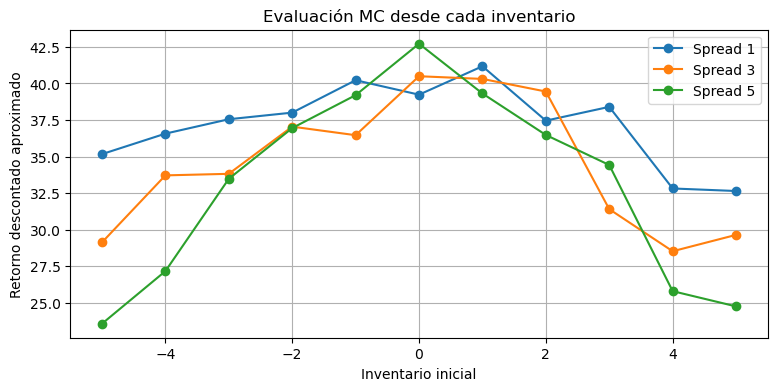

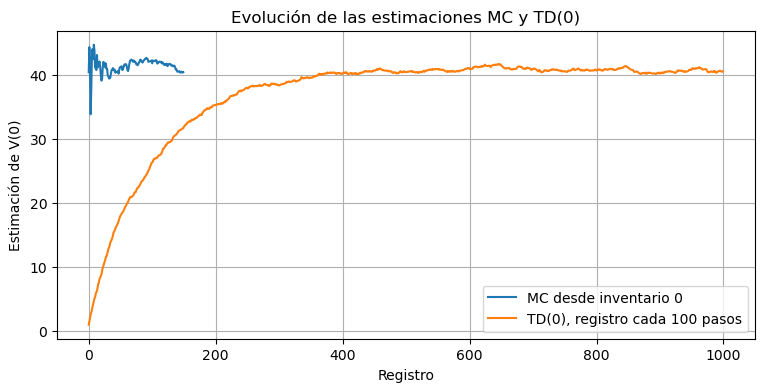

In [25]:
inventarios_posibles = np.zeros(numero_estados_mm)

for indice in range(numero_estados_mm):
    inventarios_posibles[indice] = (
        indice - inventario_maximo
    )

plt.figure(figsize=(9, 4))

for indice_spread in range(numero_spreads):
    plt.plot(
        inventarios_posibles,
        valores_mc_mm[indice_spread, :],
        marker='o',
        label='Spread ' + str(spreads[indice_spread])
    )

plt.xlabel('Inventario inicial')
plt.ylabel('Retorno descontado aproximado')
plt.title('Evaluación MC desde cada inventario')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(
    historiales_mc_mm[1, :],
    label='MC desde inventario 0'
)
plt.plot(
    historial_td_mm,
    label='TD(0), registro cada 100 pasos'
)
plt.xlabel('Registro')
plt.ylabel('Estimación de V(0)')
plt.title('Evolución de las estimaciones MC y TD(0)')
plt.legend()
plt.grid()
plt.show()


---

## Ejercicio abierto — Ejecución óptima de órdenes

**Bancolombia Capital** necesita vender una orden durante 12 intervalos. Para mantener la convención de esta semana, el período se controla externamente en el ciclo del episodio y no se añade al estado tabular.

| Componente | Definición |
|:---|:---|
| Estado | $(q,p)$: bloques pendientes y nivel de precio |
| Período | Variable externa $0,1,\ldots,11$ |
| Acción | Bloques a vender ahora: 0, 1, 2 o 3, sin exceder $q$ |
| Precio de ejecución | $p_{ejec}=p-0.001a$ |
| Recompensa | Ingreso de la venta actual: $a\,p_{ejec}$ |
| Precio siguiente | Cambio -1, 0 o +1, recortado entre 98 y 102 |
| Liquidación final | Los bloques restantes se venden a $p-2$; este es un ingreso positivo, no una penalización negativa igual a todo el valor vendido |

### Tareas

1. Implemente `paso_ejecucion(q, p, a)` sin clases.
2. Defina TWAP, front-loaded y back-loaded. La acción debe ser entera, no mayor que 3 y no mayor que $q$.
3. Evalúe mediante MC el ingreso esperado desde cada estado inicial $(q,p)$ al comienzo del día.
4. Compare las políticas con escenarios comunes e intervalos emparejados de las diferencias.
5. Explique por qué TD(0) con una sola tabla $V(q,p)$ sería solo una aproximación en este problema finito. Una implementación exacta requeriría distinguir el tiempo restante, lo cual no haremos en este ejercicio.


### Verificación manual

Estado inicial: $q=5$, $p=100$. Se venden dos bloques.


In [26]:
bloques_pendientes = 5
precio = 100
cantidad_vendida = 2

precio_ejecucion = (
    precio - 0.001 * cantidad_vendida
)

ingreso = (
    cantidad_vendida * precio_ejecucion
)

bloques_restantes = (
    bloques_pendientes - cantidad_vendida
)

print('Precio de ejecución:', round(precio_ejecucion, 4))
print('Ingreso:', round(ingreso, 4))
print('Bloques restantes:', bloques_restantes)


Precio de ejecución: 99.998
Ingreso: 199.996
Bloques restantes: 3


### Guía para solicitar apoyo de una IA

Pida una solución con las siguientes restricciones:

- sin clases;
- sin `zip` ni `enumerate`;
- sin comprensiones de listas o diccionarios;
- sin funciones `lambda`;
- políticas escritas con `if`, `elif` y `else`;
- TWAP debe usar una cantidad entera, por ejemplo `ceil(q / periodos_restantes)`, y luego limitarse por 3 y por $q$;
- el precio siguiente debe permanecer entre 98 y 102;
- la liquidación forzada debe sumar el ingreso $q(p-2)$;
- MC debe iniciar cada episodio en el estado cuya estimación $V_0(q,p)$ se desea obtener;
- las políticas deben compararse sobre los mismos escenarios aleatorios.


In [ ]:
# Escriba aquí la solución del ejercicio abierto.



---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo · Semana 12</small>